<a href="https://colab.research.google.com/github/Memucan-ctrl/codveda-ml-internship/blob/main/level2_task1_logistic_regression/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Level 2 — Task 1: Logistic Regression (Binary Classification)

Dataset: Breast Cancer Wisconsin (sklearn)
Model: LogisticRegression on standardized features
Results: Accuracy = 0.982, Precision = 0.986, Recall = 0.986, AUC = 0.99
Top predictor: mean compactness (odds ratio 1.91)

Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
AUC      : 0.9953703703703703
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

                    feature      coef  odds_ratio
5          mean compactness  0.648342    1.912367
15        compactness error  0.647227    1.910236
19  fractal dimension error  0.437894    1.549441
18           symmetry error  0.360492    1.434034
11            texture error  0.248823    1.282515
9    mean fractal dimension  0.199732    1.221075
16          concavity error  0.160563    1.174171
25        worst compactness  0.055514    1.057084
14         smoothness error -0.160276    0.851909
8             mean symmetry -0.167233    0.846003


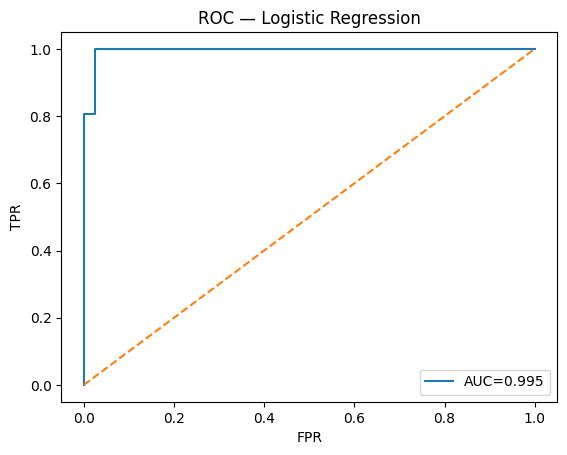

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, classification_report)

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(X_train_s, y_train)

y_pred  = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('AUC      :', roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

# Odds ratios
odds = pd.DataFrame({'feature': X.columns,
                     'coef': model.coef_[0],
                     'odds_ratio': np.exp(model.coef_[0])})
print(odds.sort_values('odds_ratio', ascending=False).head(10))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — Logistic Regression')
plt.legend(); plt.show()